# Single-Cell Analysis of Tumor Heterogeneity

## Objective
To characterize intra-tumor heterogeneity by identifying distinct cellular populations using single-cell RNA-seq data.

In [1]:
pip install scanpy anndata

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 8.5 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 2.8 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.2 MB/s  0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.2 MB 2.0 MB/s eta 0:00:02
   ------------- -------------------------- 1.0/3.2 MB 1.9 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.9 MB/s eta 0:00:01
   ----------------------- ---------------- 1.8/3.2 MB 1.9

## Load data

In [2]:
import scanpy as sc

adata = sc.read_h5ad("breast_cancer_sc.h5ad")
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

## Quick overview

In [6]:
adata.obs.head()
adata.var.head()

""
index
A1BG-AS1
A2M
A2M-AS1
A4GALT
AAAS


 ## Basic preprocessing

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

## PCA + UMAP

E:\conda_envs\tcga_project\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


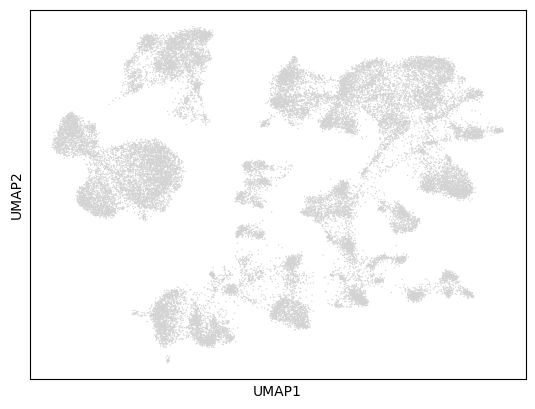

In [10]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(adata)

## Clustering

In [13]:
!pip install igraph

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 1.5 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.2 MB 1.2 MB/s eta 0:00:03
   ------------- -------------------------- 1.0/3.2 MB 1.3 MB/s eta 0:00:02
   ---------------- ----------------------- 1.3/3.2 MB 1.3 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.3 MB/s eta 0:00:02
   -------------------------- ------------- 2.1/3.2 MB 1.4 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 1.4 MB/s eta 0:00:01
   -------------------------------- ------- 2.6/3.2 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------  3.1/3.2 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 1.5 MB/s  0:00:02

   -------------------- ------------------- 1/2 [igraph]
   -------------------- ------------------- 1/2

In [15]:
!pip install leidenalg

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   -------------------------- ------------- 1.3/2.0 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.2 MB/s  0:00:00


E:\Temp\Temp\ipykernel_30668\2943136771.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


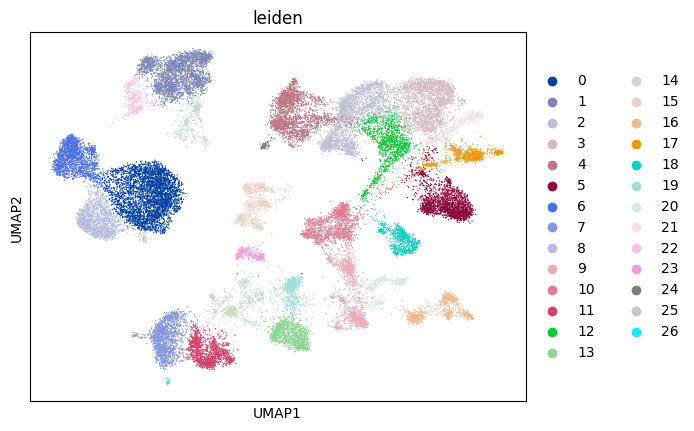

In [16]:
sc.tl.leiden(adata)

sc.pl.umap(adata, color=['leiden'])

## Marker genes

E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usu

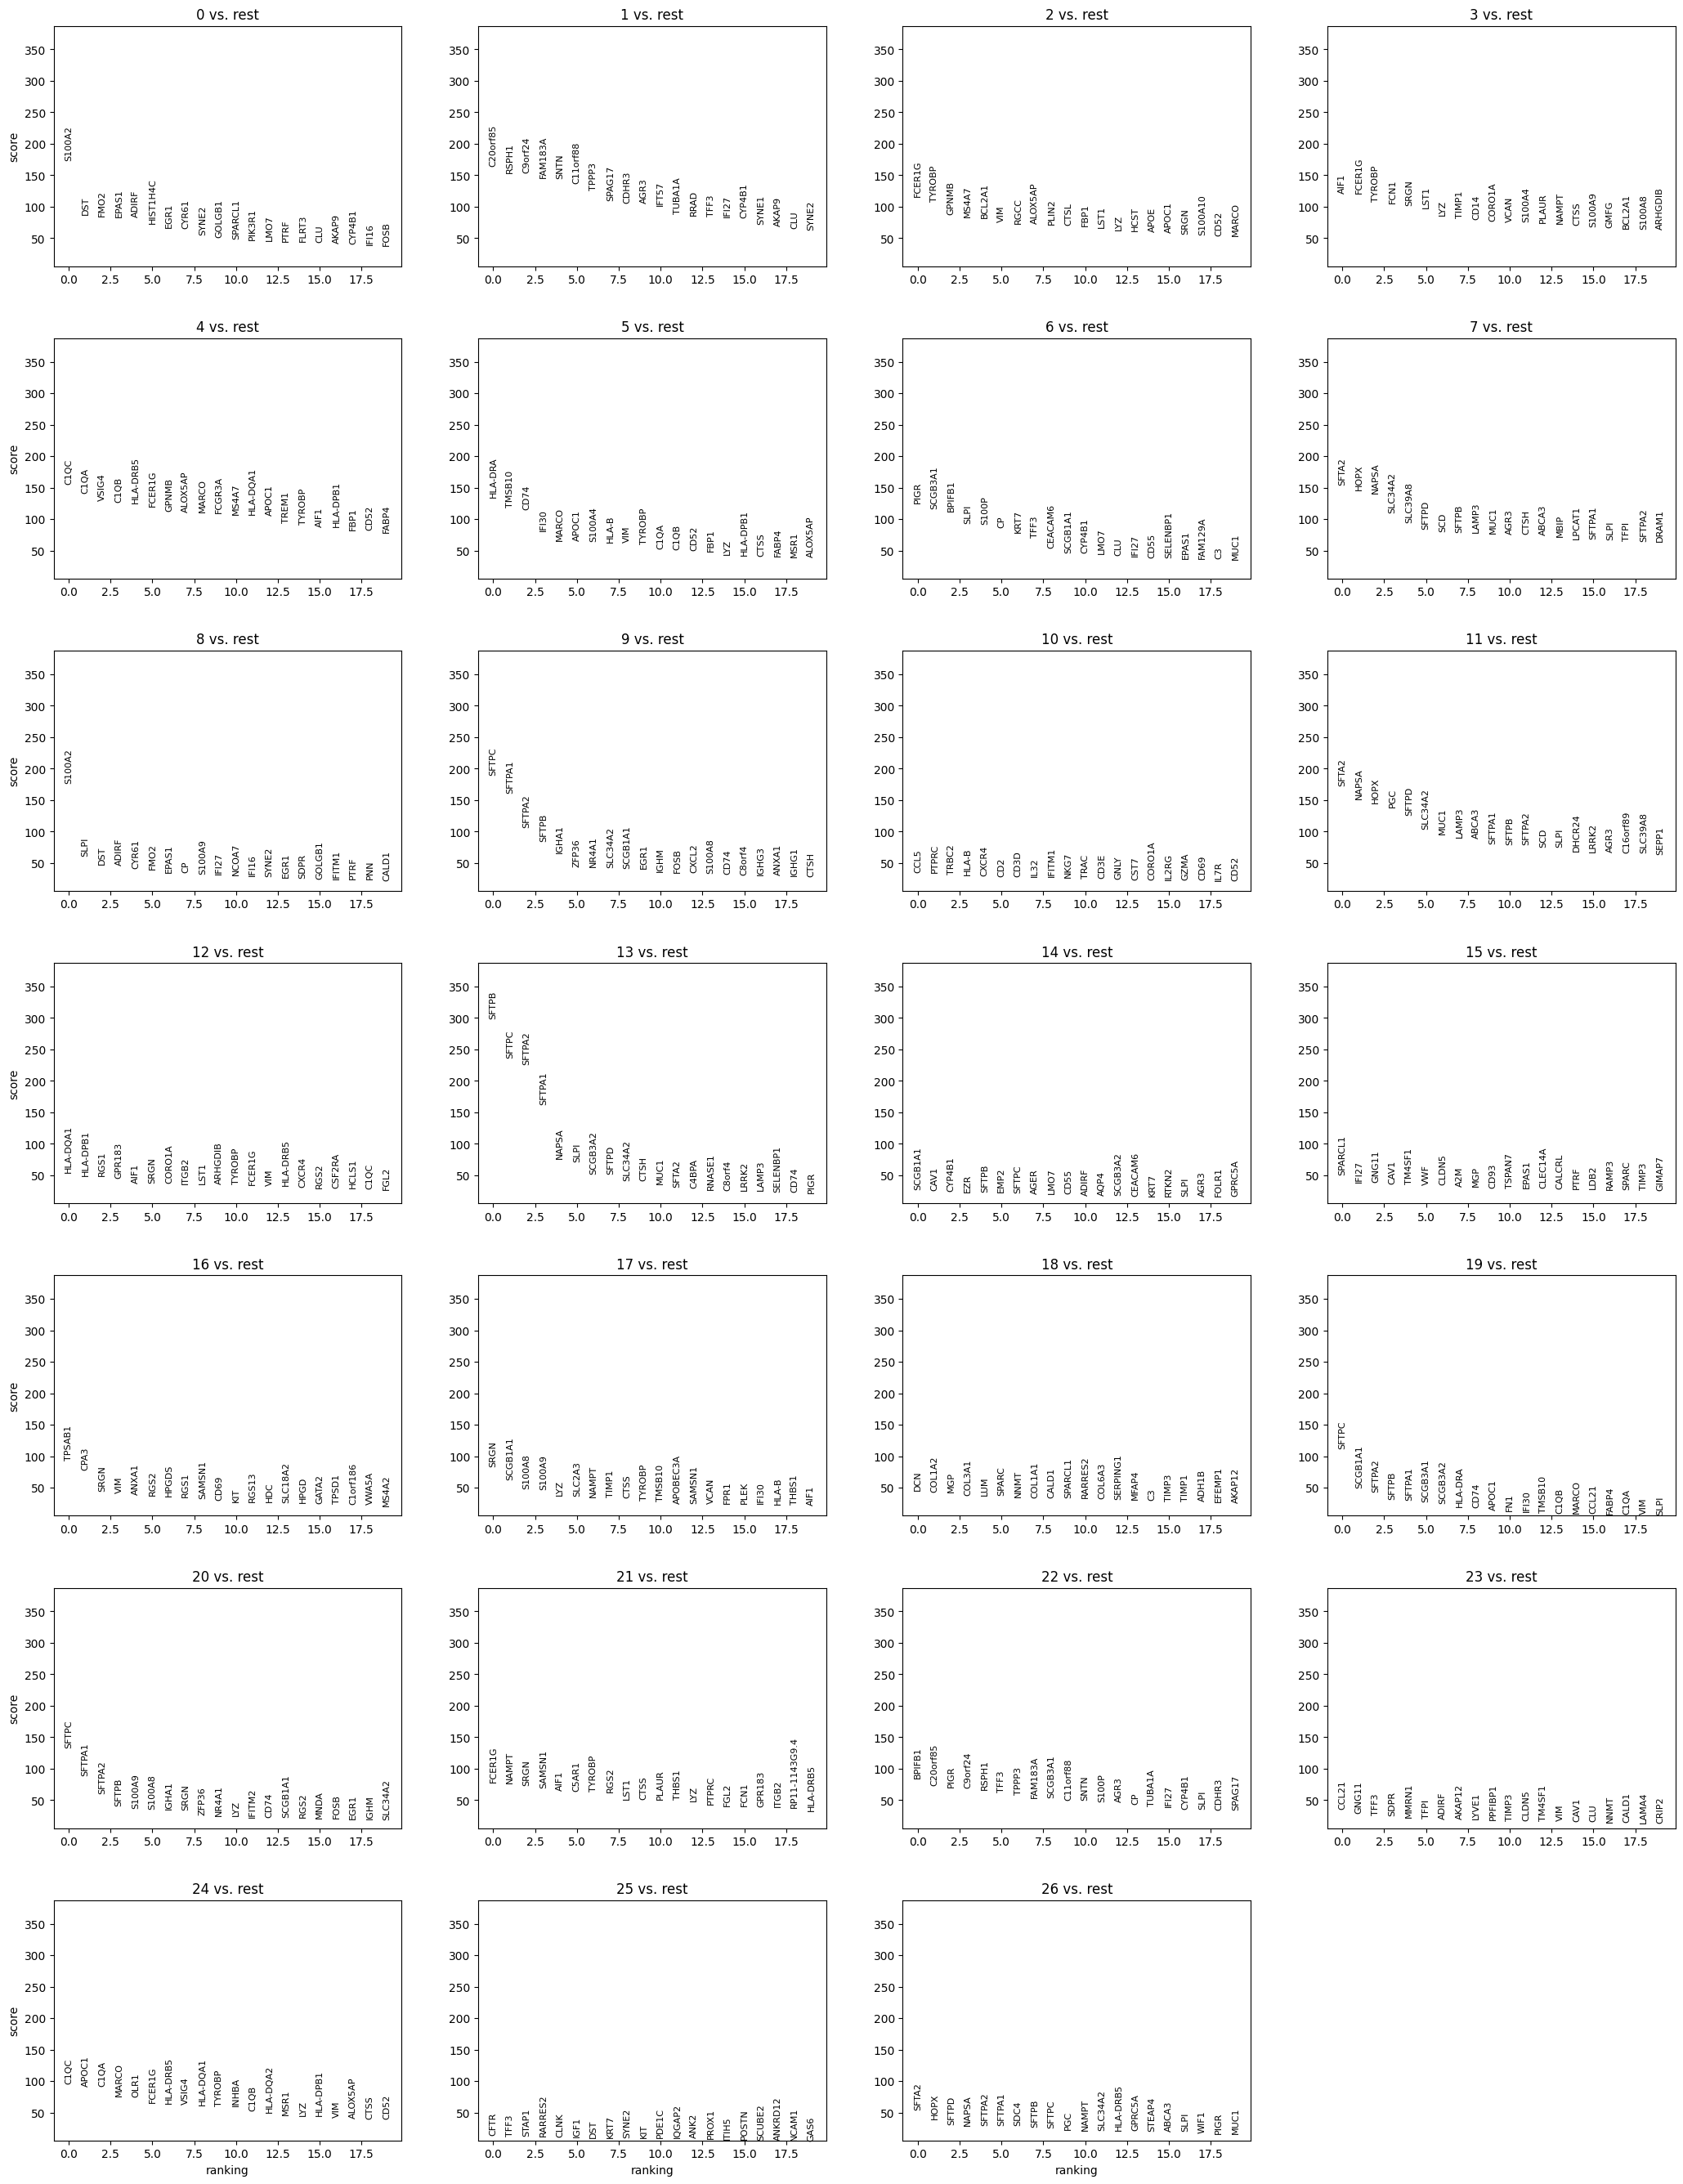

In [17]:
sc.tl.rank_genes_groups(adata, 'leiden')
sc.pl.rank_genes_groups(adata)

In [ ]:
# Interpretation

In [ ]:
clusters represent:

tumor cells
immune cells
stromal cells

In [ ]:
Single-cell analysis reveals multiple transcriptionally distinct cell populations within the tumor, highlighting intra-tumor heterogeneity

In [ ]:
INTERPRETATION

Right now you see colors
We need to turn that into:

-> biological meaning

## STEP 1 — Show clusters clearly

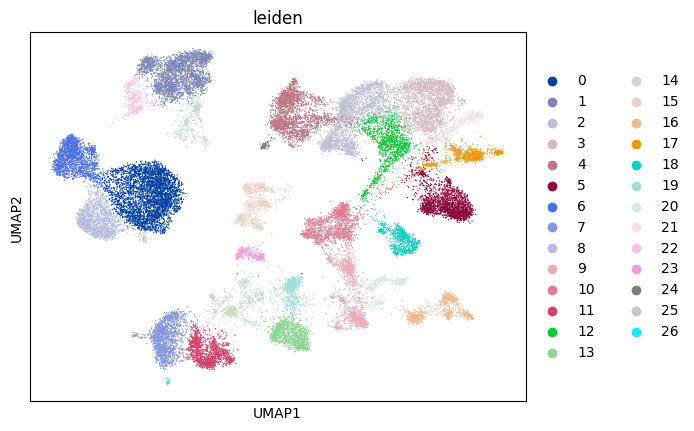

In [18]:
sc.pl.umap(adata, color=['leiden'])

In [ ]:
Cells in same cluster behave similarly
Different clusters = different cell types

## STEP 2 - Find marker genes

E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
E:\conda_envs\tcga_project\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usu

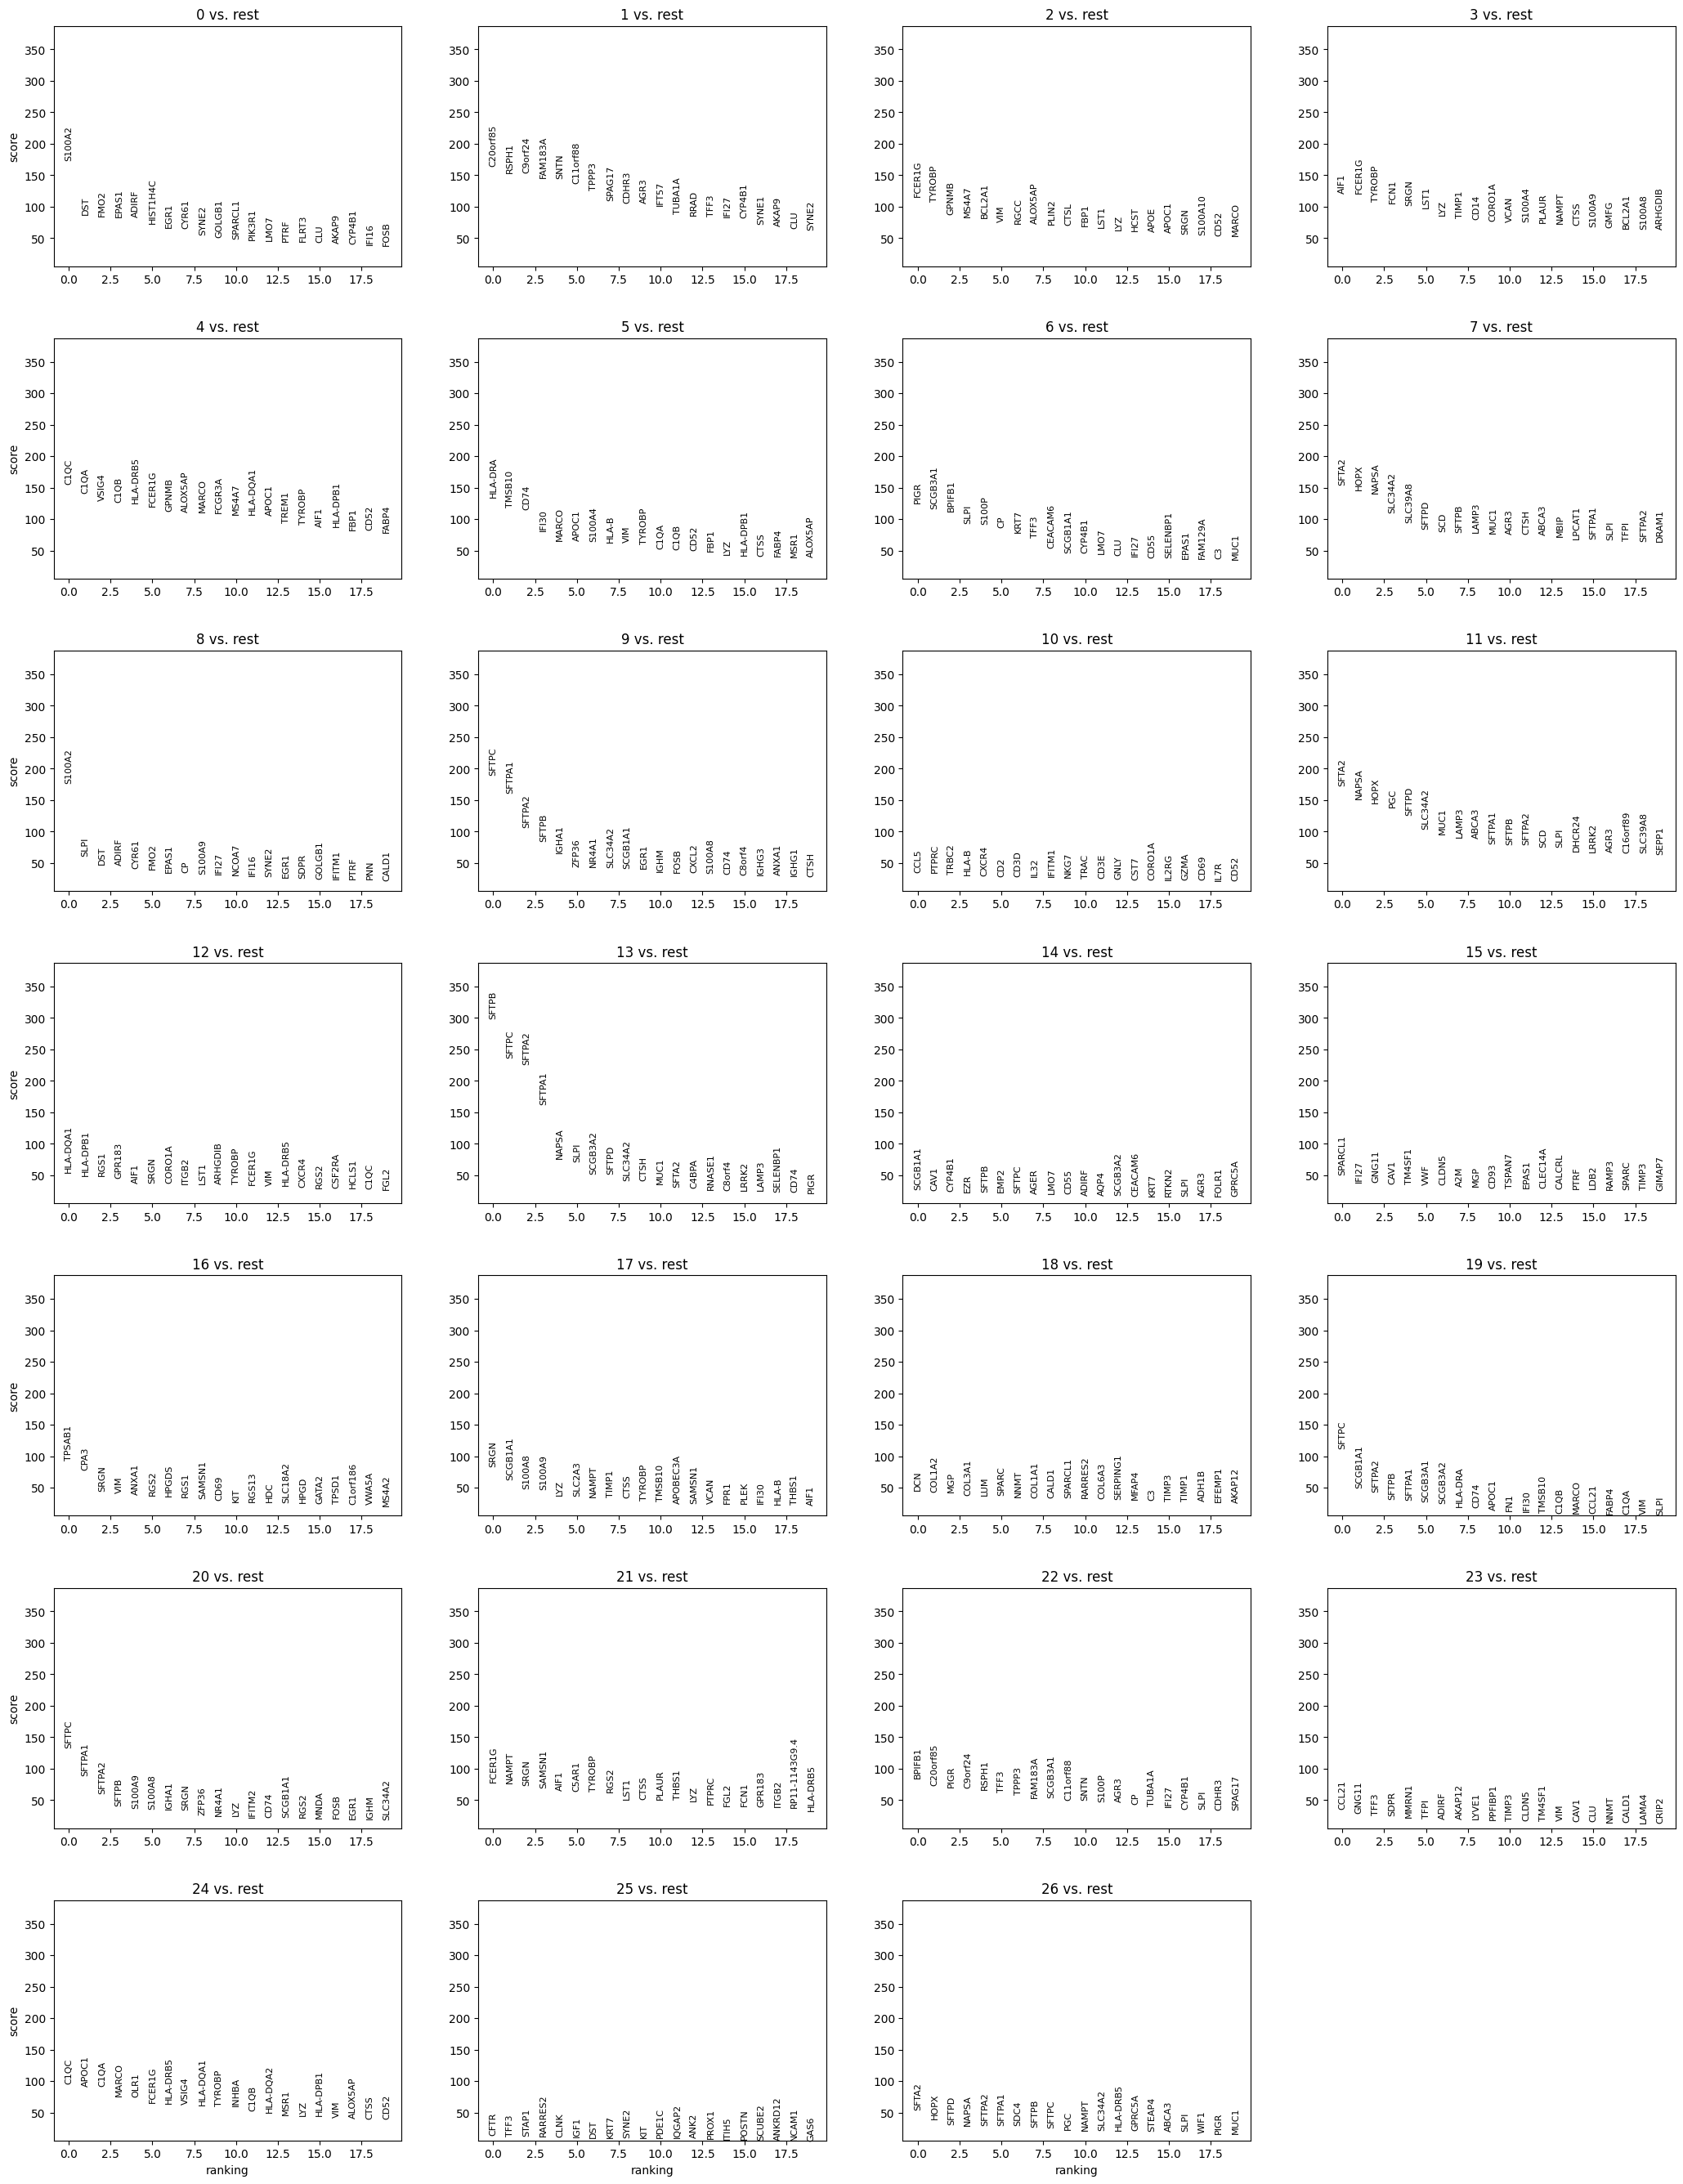

In [19]:
sc.tl.rank_genes_groups(adata, 'leiden')
sc.pl.rank_genes_groups(adata)

In [ ]:
Top genes for each cluster

In [ ]:
# Interpret clusters

In [ ]:
Tumor is NOT one thing.

It contains:

Tumor cells
Cluster 0
Cluster 1

Immune cells
Cluster 2 (macrophages)
Cluster 3 (T/NK cells)

In [ ]:
Single-cell analysis reveals that the tumor microenvironment consists of multiple distinct cell populations, 
including epithelial tumor cells and diverse immune cell types. 
This highlights significant intra-tumor heterogeneity and active tumor-immune interactions

In [ ]:
##  Biological Interpretation

Single-cell analysis reveals distinct cellular populations within the tumor, including epithelial tumor cells and immune cells such as macrophages 
and cytotoxic T/NK cells. This highlights significant intra-tumor heterogeneity and suggests active interactions between tumor 
and immune components.

In [ ]:
## Biological Interpretation
Single-cell analysis reveals multiple distinct cellular populations within the tumor, including epithelial tumor cells and immune cells such 
as macrophages and cytotoxic T/NK cells.

This highlights significant intra-tumor heterogeneity and suggests active tumor-immune interactions within the tumor microenvironment.

Representative clusters were selected to highlight intra-tumor heterogeneity.

- Cluster 0 shows high expression of epithelial markers such as KRT8, indicating tumor cells.
- Cluster 1 represents a distinct tumor subtype with altered signaling and differentiation.
- Cluster 2 is enriched for immune-related genes such as FCER1G and C1QA, suggesting tumor-associated macrophages.
- Cluster 3 shows high expression of cytotoxic genes such as GZMB and NKG7, indicating T/NK cells.

These findings demonstrate that the tumor microenvironment consists of multiple interacting cell populations, highlighting significant intra-tumor 
heterogeneity.

In [ ]:
These findings complement bulk RNA-seq analysis, where tumor subtypes were identified across patients, by revealing heterogeneity within 
individual tumors at the cellular level.